Optimize the power consumption of Zone 1 based on various environmental and meteorological factors in Wellington, New-Zealand


# Problem Statement

The objective is to develop a machine learning model that can predict the power consumption (Zone 1 Power Consumption) of Wellington, New Zealand based on various environmental and meteorological factors. The goal is to create an accurate predictive model that can assist in managing energy resources efficiently and optimizing power consumption in that zone.


Sr no. Serial Number
Temperature: The temperature in Celsius at the specific location.
Humidity: The relative humidity percentage at the location. (g.m-3, i.e. units of grams of water vapor per cubic meter of air. )
Wind Speed: The speed of the wind at the location. (nautical mile per hour )
General Diffuse Flows: Refer to a specific measurement or calculation related to the amount or intensity of diffuse solar radiation in a particular area. (Mtr sqr per sec )
Diffuse Flows: The measure of diffuse solar radiation. (Mtr sqr per sec )
Air Quality Index: An index representing the air quality in the area. (particles in micrograms per cubic meter. )
Cloudiness: The level of cloud cover or cloudiness at the location. (1-Yes,0-No)
Zone 1 Power Consumption: The power consumption in the specific zone, which is the target variable to be predicted. (in KWR- Target value)

In [2]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')
import re

from scipy.stats import normaltest, shapiro, boxcox
import scipy.stats as stats

In [3]:
# Read the data
data = pd.read_csv("city_power_consumption.csv")
data.head()

,S no,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,1,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,2,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,3,6.313,74.5,0.08,0.062,0.100,151.0,1,29128.10127
3,4,6.121,75,0.083,0.091,0.096,151.0,1,28228.86076
4,5,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


In [4]:
data.columns

Index(['S no', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Air Quality Index (PM)',
       'Cloudiness', ' Power Consumption in A Zone'],
      dtype='object')

In [5]:
data.shape

(52583, 9)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   S no                          52583 non-null  int64  
 1   Temperature                   52263 non-null  object 
 2   Humidity                      52558 non-null  object 
 3   Wind Speed                    52512 non-null  object 
 4   general diffuse flows         52275 non-null  float64
 5   diffuse flows                 52568 non-null  float64
 6   Air Quality Index (PM)        52565 non-null  float64
 7   Cloudiness                    52583 non-null  int64  
 8    Power Consumption in A Zone  52583 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 3.6+ MB


In [7]:
data.head()

,S no,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,1,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,2,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,3,6.313,74.5,0.08,0.062,0.100,151.0,1,29128.10127
3,4,6.121,75,0.083,0.091,0.096,151.0,1,28228.86076
4,5,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


S.No column can be deleted, its just a serial number, the index of the dataframe is same as the S.No. Its redundant, so we can delete it.

In [8]:
data.drop("S no", axis = 1, inplace =True)
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,6.313,74.5,0.08,0.062,0.100,151.0,1,29128.10127
3,6.121,75,0.083,0.091,0.096,151.0,1,28228.86076
4,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


Temperature, Humidity and Wind Speed are numerical values but the datatype is Object. We can convert the data type to float. 

Before that we have to check if there are any values which have any non numeric values.

In [9]:
# Checking for values containing any space followed by cgaracters
data[data['Temperature'].str.contains(r'\s\w+', regex = True) == True]

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
470,5.488 dc,87.1,0.087,0.029,0.134,152.0,0,15337.38602
1757,13.65 CD,85.3,0.076,NaN,0.178,158.0,0,13422.49240
2287,12.31 dc,58.24,0.079,NaN,0.111,153.0,0,26418.23708


In [10]:
# replacing the space and characters with '' 
data['Temperature'] = data['Temperature'].apply(lambda x: re.sub(r'[\sa-zA-Z]','',str(x)))
data[data['Temperature'].str.contains(r'\s\w+', regex = True) == True]

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone


In [11]:
# Checking for any empty string values in the temperature column
data[data['Temperature'].astype(str).str.strip() == '']

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
87,,54.06,0.075,449.2,41.52,152.0,1,18036.47416
88,,55.56,0.075,437.4,44.13,151.0,1,17996.35258
89,,56.69,0.077,422.0,43.87,159.0,1,17952.58359
90,,57.26,0.077,409.0,44.90,157.0,1,17894.22492
91,,57.96,0.074,391.8,46.89,153.0,1,17846.80851
...,...,...,...,...,...,...,...,...
52578,,75.6,0.094,436.2,38.96,157.0,0,34444.55696
52579,,73.5,0.089,451.6,37.73,157.0,0,34438.48101
52580,,70.1,0.085,466.4,37.49,157.0,0,33873.41772
52581,,67.75,0.086,477.0,37.37,152.0,0,33988.86076


320 rows have empty string in the temperature column. We can replace them with NaN as Temperature will converted to a float data type

In [12]:
# replacing '' with 0.0 and checking
data['Temperature'] = data['Temperature'].replace('','NaN')
data[data['Temperature'].astype(str).str.strip() == '']

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone


In [13]:
# Convert the Temperature column to float data type
data['Temperature'] = data['Temperature'].astype(float)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Temperature                   52263 non-null  float64
 1   Humidity                      52558 non-null  object 
 2   Wind Speed                    52512 non-null  object 
 3   general diffuse flows         52275 non-null  float64
 4   diffuse flows                 52568 non-null  float64
 5   Air Quality Index (PM)        52565 non-null  float64
 6   Cloudiness                    52583 non-null  int64  
 7    Power Consumption in A Zone  52583 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 3.2+ MB


Cleaning up Humidity Column

In [14]:
# Checking for values containing any space followed by characters in Humidity
data[data['Humidity'].str.contains(r'\s\w+', regex = True) == True]

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
719,9.11,84.8 i,0.088,0.033,0.156,155.0,0,19575.68389


In [15]:
# replacing the space and characters with '' 
data['Humidity'] = data['Humidity'].apply(lambda x: re.sub(r'[\sa-zA-Z]','',str(x)))
data[data['Humidity'].str.contains(r'\s\w+', regex = True) == True]

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone


In [16]:
# Checking for any empty string values in the temperature column
data[data['Humidity'].astype(str).str.strip() == '']

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
1045,NaN,,0.09,NaN,0.163,156.0,0,13991.48936
1152,NaN,,0.076,NaN,0.156,152.0,0,17387.23404
1195,NaN,,0.075,NaN,0.152,153.0,0,15417.62918
1275,NaN,,0.071,NaN,0.208,151.0,0,26203.03951
1297,NaN,,0.074,NaN,0.130,NaN,0,17274.16413
1299,NaN,,0.076,NaN,0.130,NaN,0,16551.97568
1304,NaN,,0.082,NaN,0.178,NaN,0,14491.18541
1309,NaN,,0.081,NaN,0.174,NaN,0,13663.22188
1310,NaN,,0.082,NaN,0.145,NaN,0,13407.90274
40617,20.13,,NaN,NaN,0.163,156.0,0,26657.33042


In [17]:
# replacing '' with NaN and checking
data['Humidity'] = data['Humidity'].replace('','NaN')
data[data['Humidity'].astype(str).str.strip() == '']

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone


In [18]:
# Convert the Humidity column to float data type
data['Humidity'] = data['Humidity'].astype(float)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Temperature                   52263 non-null  float64
 1   Humidity                      52558 non-null  float64
 2   Wind Speed                    52512 non-null  object 
 3   general diffuse flows         52275 non-null  float64
 4   diffuse flows                 52568 non-null  float64
 5   Air Quality Index (PM)        52565 non-null  float64
 6   Cloudiness                    52583 non-null  int64  
 7    Power Consumption in A Zone  52583 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 3.2+ MB


Cleaning up Wind Speed Column

In [19]:
# Checking for values containing any space followed by cgaracters
data[data['Wind Speed'].str.contains(r'\s\w+', regex = True) == True]

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone


In [20]:
# Checking for values containing any special characters
data[data['Wind Speed'].str.contains(r'[^a-zA-Z0-9\s.]', regex = True) == True]

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
41,4.29,77.0,8.50%,0.033,0.193,158.0,1,12908.20669
139,12.07,70.7,8.50%,0.033,0.078,151.0,1,20768.38906
144,11.01,75.8,8.50%,0.033,0.163,156.0,1,18047.41641
174,10.03,83.8,8.50%,0.029,0.163,153.0,1,13517.32523


In [21]:
# replacing the special characters with '' 
data['Wind Speed'] = data['Wind Speed'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s.]','',str(x)))
data[data['Wind Speed'].str.contains(r'[^a-zA-Z0-9\s.]', regex = True) == True]

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone


In [22]:
# Convert the Wind Speed column to float data type
data['Wind Speed'] = data['Wind Speed'].astype(float)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Temperature                   52263 non-null  float64
 1   Humidity                      52558 non-null  float64
 2   Wind Speed                    52512 non-null  float64
 3   general diffuse flows         52275 non-null  float64
 4   diffuse flows                 52568 non-null  float64
 5   Air Quality Index (PM)        52565 non-null  float64
 6   Cloudiness                    52583 non-null  int64  
 7    Power Consumption in A Zone  52583 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 3.2 MB


Checking for null values in each column

In [23]:
data.isnull().sum()

Temperature                     320
Humidity                         25
Wind Speed                       71
general diffuse flows           308
diffuse flows                    15
Air Quality Index (PM)           18
Cloudiness                        0
 Power Consumption in A Zone      0
dtype: int64

In [24]:
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,6.313,74.5,0.080,0.062,0.100,151.0,1,29128.10127
3,6.121,75.0,0.083,0.091,0.096,151.0,1,28228.86076
4,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


In [25]:
data.describe()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
count,52263.000000,52558.00000,52512.000000,52275.000000,52568.000000,52565.000000,52583.000000,52583.000000
mean,18.827384,68.28577,1.955961,182.964247,74.872330,154.499191,0.009338,31061.821779
std,5.813293,15.54517,2.348552,264.571351,124.084858,2.871553,0.096180,8021.057455
min,3.247000,11.34000,0.050000,0.004000,0.011000,150.000000,0.000000,9457.750760
25%,14.430000,58.33000,0.078000,0.062000,0.122000,152.000000,0.000000,24738.858990
50%,18.820000,69.88500,0.086000,5.226000,4.412000,155.000000,0.000000,31189.787230
75%,22.910000,81.40000,4.915000,320.100000,100.500000,157.000000,0.000000,36721.582445
max,40.010000,94.80000,8.500000,1163.000000,936.000000,159.000000,1.000000,52204.395120


Temperature: The average value is 18.8 deg C. The range of temperature is between 3.2 to 40 deg C. This shows that there might not be any outliers in the data. We will be checking for outliers later, but for now, the mean value can be used to impute the missing values.

In [26]:
# Imputing missing values using the mean value
data['Temperature'] = data['Temperature'].fillna(data['Temperature'].mean())

In [27]:
data.isnull().sum()

Temperature                       0
Humidity                         25
Wind Speed                       71
general diffuse flows           308
diffuse flows                    15
Air Quality Index (PM)           18
Cloudiness                        0
 Power Consumption in A Zone      0
dtype: int64

Humidity: Similar to the Temperature column, the mean value of relative umity percentage value is 68.2. The min and max values of Humidity dont seem to be too extream. For clarity, cross checking this info with the weather-and-climate.com website and the average humidity value is very close to this value. Using the mean to impute the missing values.

In [28]:
data['Humidity'] = data['Humidity'].fillna(data['Humidity'].mean())
data.isnull().sum()

Temperature                       0
Humidity                          0
Wind Speed                       71
general diffuse flows           308
diffuse flows                    15
Air Quality Index (PM)           18
Cloudiness                        0
 Power Consumption in A Zone      0
dtype: int64

Wind Speed: There are 71 missing values in the wind speed column. The average wind speed is 1.95 nautical miles per hour. Imputing the missing values with the mean value

In [29]:
data['Wind Speed'] = data['Wind Speed'].fillna(data['Wind Speed'].mean())
data.isnull().sum()

Temperature                       0
Humidity                          0
Wind Speed                        0
general diffuse flows           308
diffuse flows                    15
Air Quality Index (PM)           18
Cloudiness                        0
 Power Consumption in A Zone      0
dtype: int64

General Diffuse Flows: Refer to a specific measurement or calculation related to the amount or intensity of diffuse solar radiation in a particular area. (Mtr sqr per sec ). Imputing null values with mean value. The mean value is 182.96

In [30]:
data['general diffuse flows'] = data['general diffuse flows'].fillna(data['general diffuse flows'].mean())
data.isnull().sum()

Temperature                      0
Humidity                         0
Wind Speed                       0
general diffuse flows            0
diffuse flows                   15
Air Quality Index (PM)          18
Cloudiness                       0
 Power Consumption in A Zone     0
dtype: int64

Similar to the General diffuse flow, imputing the missing values in diffuse flows using the mean value which is 74.87

In [31]:
data['diffuse flows'] = data['diffuse flows'].fillna(data['diffuse flows'].mean())
data.isnull().sum()

Temperature                      0
Humidity                         0
Wind Speed                       0
general diffuse flows            0
diffuse flows                    0
Air Quality Index (PM)          18
Cloudiness                       0
 Power Consumption in A Zone     0
dtype: int64

Air Quality Index: Imputing the missing values with mean value which is 154.49

In [32]:
data['Air Quality Index (PM)'] = data['Air Quality Index (PM)'].fillna(data['Air Quality Index (PM)'].mean())
data.isnull().sum()

Temperature                     0
Humidity                        0
Wind Speed                      0
general diffuse flows           0
diffuse flows                   0
Air Quality Index (PM)          0
Cloudiness                      0
 Power Consumption in A Zone    0
dtype: int64

In [33]:
#Function to check for outliers
def check_outliers(df, col):
  """
  This function checks for outliers in the given column of the given dataframe.
  It calculates the IQR and Q1,Q3 to get the lower limit value and upper limit value.
  It returns the lower limit and upper limit values.

  Parameters:
  -----------
  df : pandas.DataFrame
      The input DataFrame containing the data.
  col : str
      The name of the column to check for outliers.

  Returns:
  --------
  LL : float
      The lower limit value.
  UL : float
      The upper limit value.

  Example:
  --------
  ll, ul = check_outliers(df, 'Age')
  """

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  LL = Q1 - 1.5 * IQR
  UL = Q3 + 1.5 * IQR

  print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR} | LL: {LL} | UL: {UL}")

  outlier_count_ul = df[df[col] > UL].shape[0]
  outlier_perc_ul = (outlier_count_ul * 100) / df.shape[0]

  outlier_count_ll = df[df[col] < LL].shape[0]
  outlier_perc_ll = (outlier_count_ll * 100) / df.shape[0]

  print(f"# of Outliers on the Higher Side: {outlier_count_ul} | % of Outliers on the Higher Side: {outlier_perc_ul}%")
  print(f"# of Outliers on the Lower Side: {outlier_count_ll} | % of Outliers on the Lower Side: {outlier_perc_ll}%")

  return LL, UL

In [34]:
# Function to check the data distribution
def col_distribution(df, col_name):
  """
  This function plots a distplot and a box plot for the given column of the given dataframe.
  It also calculates the skewness and kurtosis of the data.
  It also uses the check_outliers function to check for outliers.

  Parameters:
  -----------
  df : pandas.DataFrame
      The input DataFrame containing the data.
  col_name : str
      The name of the column.

  Returns:
  --------
  LL : float
      The lower limit value.
  UL : float
      The upper limit value.

  Example:
  --------
  ll, ul = col_distribution(df, 'Age')

  """
  print(f"********** Data Distribution - {col_name} *********")
  plt.figure(figsize=(15,4))
  plt.subplot(1,2,1)
  sns.distplot(df[col_name])

  plt.subplot(1,2,2)
  sns.boxplot(df[col_name])
  print("The skewness for the original data is {}.".format(df[col_name].skew()))
  print("The kurtosis for the original data is {}.".format(df[col_name].kurt()))

  print()
  print(f"********** Outlier Detection - {col_name} *********")
  ll, ul = check_outliers(df, col_name)
  print()
  return ll, ul

In [35]:
data.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows',
       'diffuse flows', 'Air Quality Index (PM)', 'Cloudiness',
       ' Power Consumption in A Zone'],
      dtype='object')

Checking for outliers using the box plot and data distribution using the distplot

Temperature: 

********** Data Distribution - Temperature *********


The skewness for the original data is 0.19437189723069717.
The kurtosis for the original data is -0.2853619731740755.

********** Outlier Detection - Temperature *********
Q1: 14.45 | Q3: 22.87 | IQR: 8.420000000000002 | LL: 1.8199999999999967 | UL: 35.5
# of Outliers on the Higher Side: 154 | % of Outliers on the Higher Side: 0.29287031930471824%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



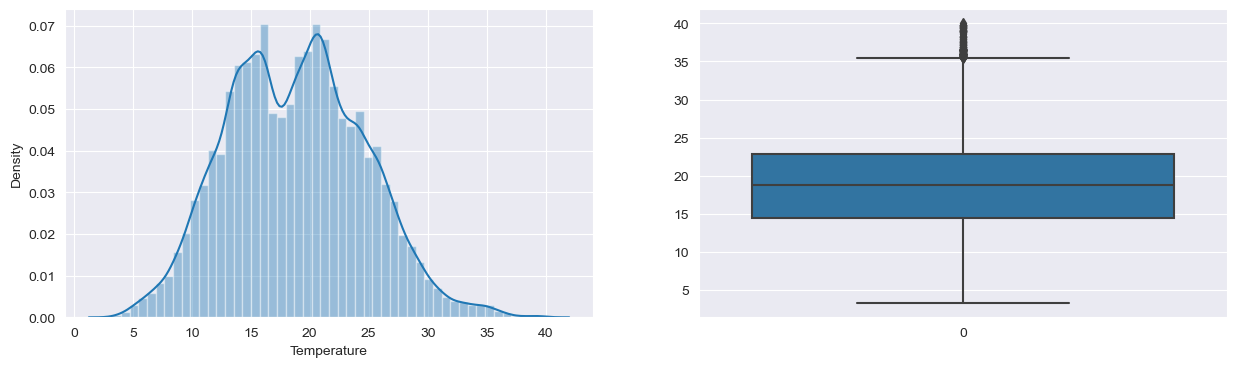

In [36]:
temp_ll, temp_ul = col_distribution(data, 'Temperature')

There is slight +ve skewness, the distribution is fairly symmetrical. Skewness value is 0.19 which is between 0 to 0.5, which means its aproximately symetric. The slight right skew indicates the few outliers that are present in the data. The kurtosis is less than 3 which indicates the curve is slightly platykurtic. 

The box plot indicates there are some outliers on the higher side of the data. These outliers can be treated using the capping method using the upperlimit value which is stored in the temp_ul variable. 

In [37]:
data['Temperature'] = np.where(data['Temperature'] >= temp_ul, temp_ul, data['Temperature'])

********** Data Distribution - Temperature *********
The skewness for the original data is 0.1768912358481948.
The kurtosis for the original data is -0.34798835253127436.

********** Outlier Detection - Temperature *********
Q1: 14.45 | Q3: 22.87 | IQR: 8.420000000000002 | LL: 1.8199999999999967 | UL: 35.5
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



(1.8199999999999967, 35.5)

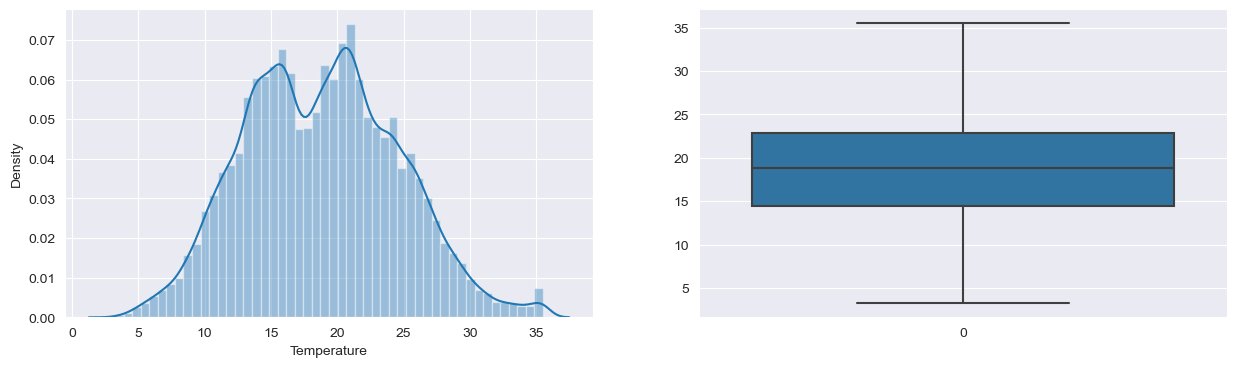

In [38]:
col_distribution(data, 'Temperature')

Humidity: The relative humidity percentage at the location. (g.m-3, i.e. units of grams of water vapor per cubic meter of air.)

********** Data Distribution - Humidity *********
The skewness for the original data is -0.6274390695048774.
The kurtosis for the original data is -0.11746729819129476.

********** Outlier Detection - Humidity *********
Q1: 58.34 | Q3: 81.4 | IQR: 23.060000000000002 | LL: 23.75 | UL: 115.99000000000001
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 295 | % of Outliers on the Lower Side: 0.5610178194473499%



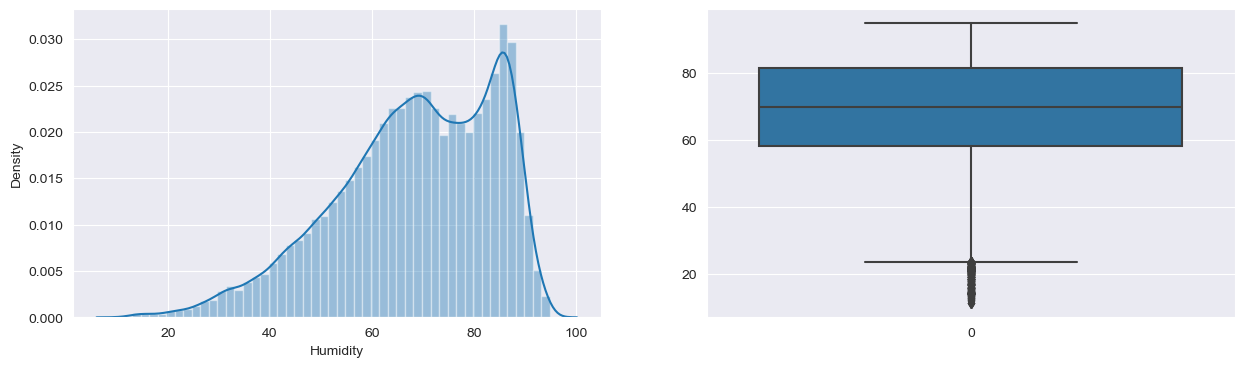

In [39]:
humidity_ll, humidity_ul = col_distribution(data, 'Humidity')

The data is left skewed as the skewness is negetive. The skewness values is -0.6 which is between -1 and -0.5, so its moderately skewed. The skewness on the left indicates outliers.
Kurtosis is -0.11, which is < 3, indicates the curve is platykurtic. The tails are extended to the left indicating outliers.

First treating the outliers using the capping method. humidity_ll has the lower limit value, which can be used for capping.


In [40]:
data['Humidity'] = np.where(data['Humidity'] <= humidity_ll, humidity_ll, data['Humidity'])

********** Data Distribution - Humidity *********
The skewness for the original data is -0.5922537440191478.
The kurtosis for the original data is -0.262008539243181.

********** Outlier Detection - Humidity *********
Q1: 58.34 | Q3: 81.4 | IQR: 23.060000000000002 | LL: 23.75 | UL: 115.99000000000001
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



(23.75, 115.99000000000001)

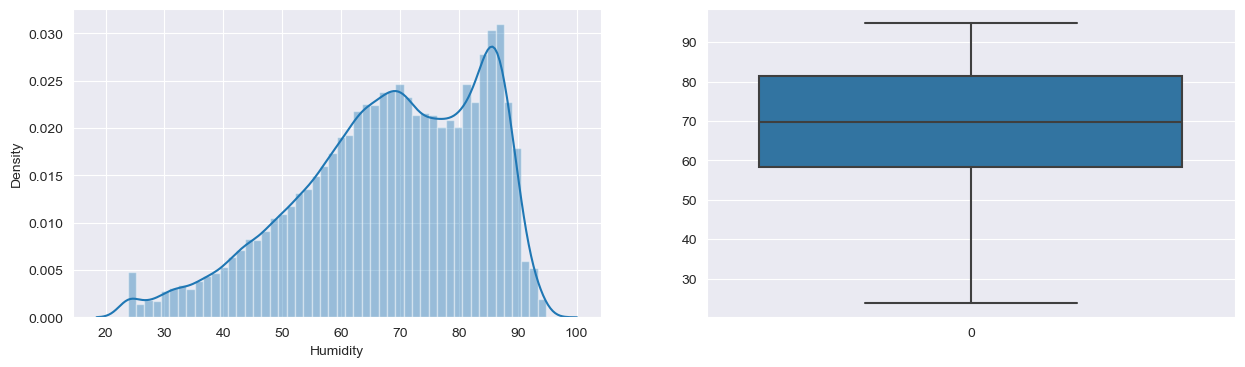

In [41]:
col_distribution(data, 'Humidity')

OUtliers are handled, now to fix the skewness, we can try the transformation techniques such as log, square root and boxcox.

In [42]:
# Function for data transformation
def check_transformation(df,col_Name):
  log_trans = np.log(df[col_Name])
  sqrt_trans = np.sqrt(df[col_Name])
  boxcox_trans, l = boxcox(df[col_Name])
  boxcox_skew = stats.skew(boxcox_trans)
  plt.figure(figsize=(15,4))
  plt.subplot(1,3,1)
  sns.distplot(log_trans).set(title = f'Log Transformation \n Skewness = {log_trans.skew():.3f}')
  plt.subplot(1,3,2)
  sns.distplot(sqrt_trans).set(title = f'Square Root Transformation \n Skewness = {sqrt_trans.skew():.3f}')
  plt.subplot(1,3,3)
  sns.distplot(boxcox_trans).set(title = f'Boxcox Transformation \n Skewness = {boxcox_skew:.3f} , lambda = {l:.3f}')

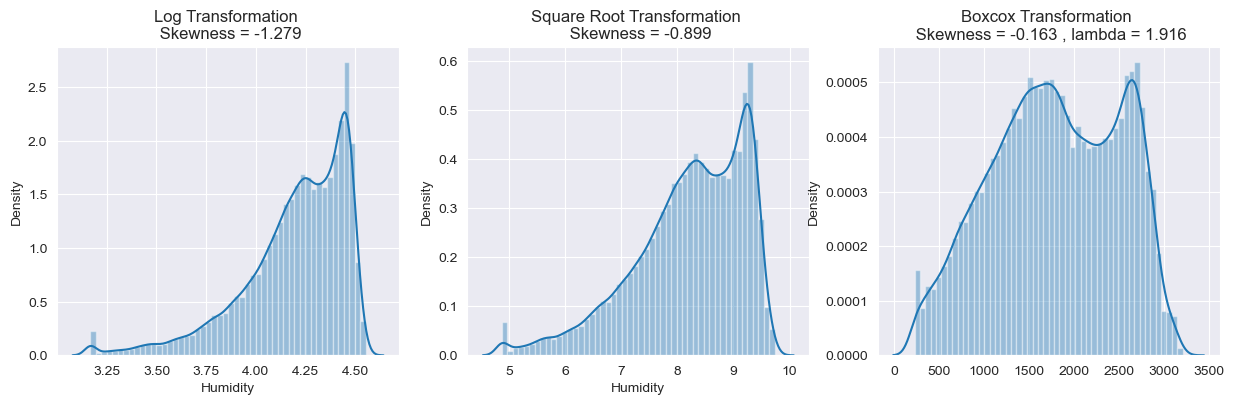

In [43]:
check_transformation(data, 'Humidity')

The boxcox transformation looks like a better option as its giving the least amount of skewness.
Applying boxcox transformation to the humidity column.

In [44]:
data['Humidity'],l = boxcox(data['Humidity'])

********** Data Distribution - Humidity *********
The skewness for the original data is -0.1626486416926747.
The kurtosis for the original data is -0.898040788082072.

********** Outlier Detection - Humidity *********
Q1: 1263.359536606338 | Q3: 2392.347273595221 | IQR: 1128.987736988883 | LL: -430.12206887698653 | UL: 4085.8288790785455
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



(-430.12206887698653, 4085.8288790785455)

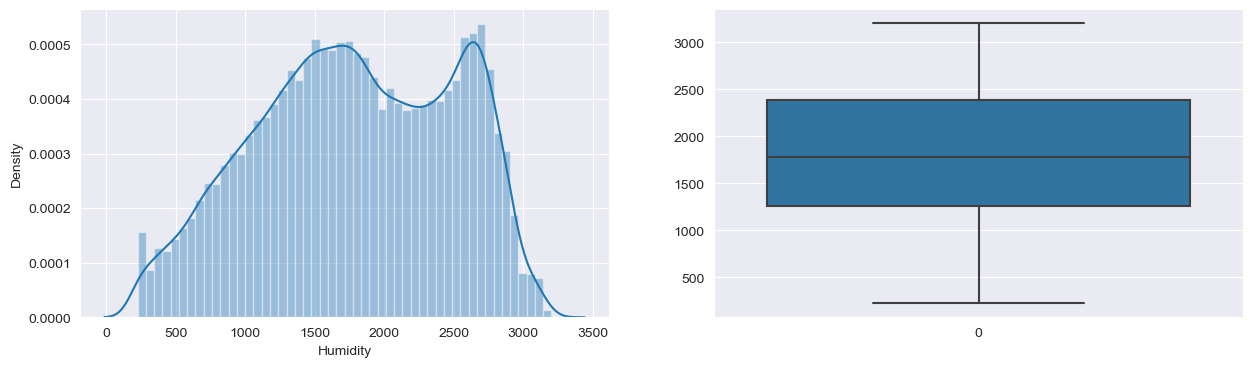

In [45]:
col_distribution(data, 'Humidity')

In [46]:
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,6.559,1982.577483,0.083,0.051,0.119,158.0,1,34055.69620
1,6.414,2018.780062,0.083,0.070,0.085,159.0,1,29814.68354
2,6.313,2018.780062,0.080,0.062,0.100,151.0,1,29128.10127
3,6.121,2044.830722,0.083,0.091,0.096,151.0,1,28228.86076
4,5.921,2081.569802,0.081,0.048,0.085,154.0,1,27335.69620


Wind Speed: The speed of the wind at the location. (nautical mile per hour )

********** Data Distribution - Wind Speed *********
The skewness for the original data is 0.4669509978978589.
The kurtosis for the original data is -1.775329333504458.

********** Outlier Detection - Wind Speed *********
Q1: 0.078 | Q3: 4.915 | IQR: 4.837 | LL: -7.177499999999999 | UL: 12.1705
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



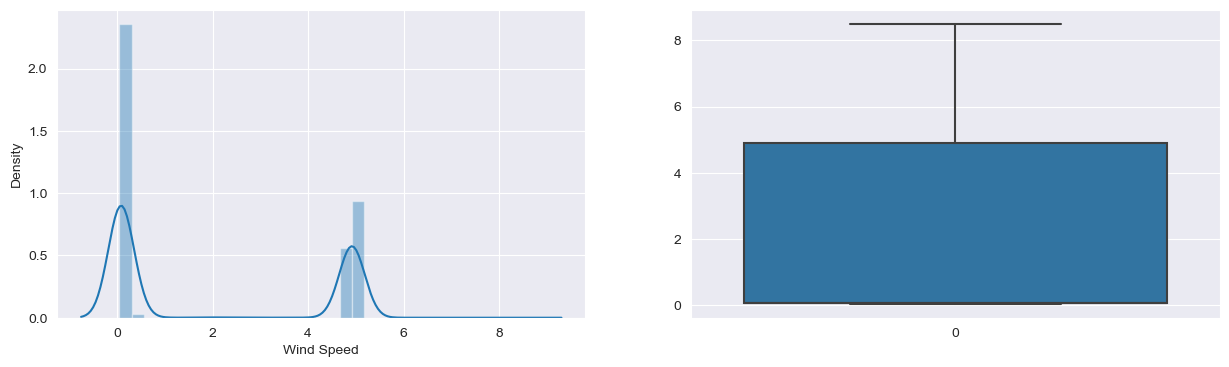

In [47]:
windspeed_ll, eindspeed_ul = col_distribution(data, 'Wind Speed')

There are no outliers in the wind speed. The data is however positively skewed but the skewness is below 0.5 which is approximately symmetric. Kurtosis value is < 3, which makes it a platykurtic curve. We are not applying any transformation or treatments, leaving it as it is.

General Diffuse Flows: Refer to a specific measurement or calculation related to the amount or intensity of diffuse solar radiation in a particular area. (Mtr sqr per sec )

********** Data Distribution - general diffuse flows *********
The skewness for the original data is 1.3090170466337676.
The kurtosis for the original data is 0.416974744412582.

********** Outlier Detection - general diffuse flows *********
Q1: 0.062 | Q3: 317.0 | IQR: 316.938 | LL: -475.34499999999997 | UL: 792.4069999999999
# of Outliers on the Higher Side: 2425 | % of Outliers on the Higher Side: 4.611756651389232%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



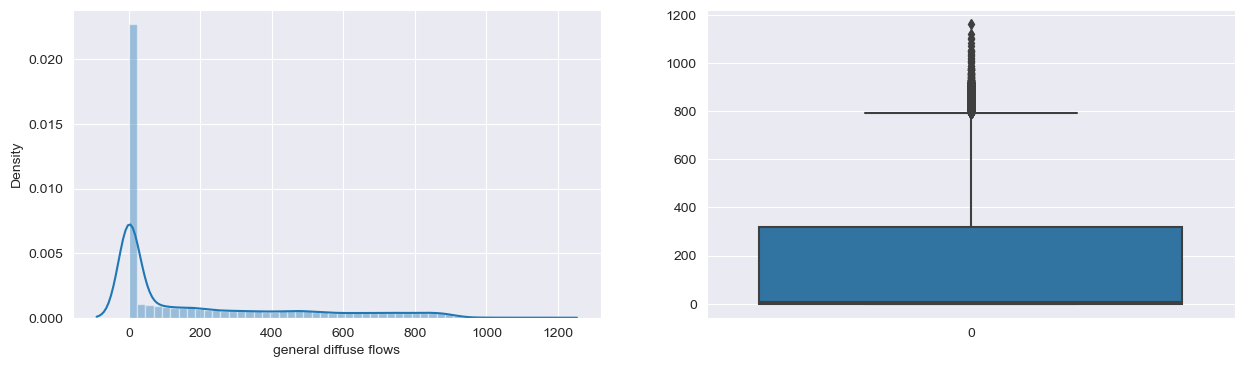

In [48]:
gdf_ll, gdf_ul = col_distribution(data, 'general diffuse flows')

Skewness is coming to 1.3 which indicates its highly skewed to the right. 
4.6% of the data are detected as outliers on the higher side. To treat the outliers, we can use the capping method using the upper limit value gdf_ul.

In [49]:
data['general diffuse flows'] = np.where(data['general diffuse flows'] >= gdf_ul, gdf_ul, data['general diffuse flows'])

********** Data Distribution - general diffuse flows *********


The skewness for the original data is 1.238516404244133.
The kurtosis for the original data is 0.128737059570752.

********** Outlier Detection - general diffuse flows *********
Q1: 0.062 | Q3: 317.0 | IQR: 316.938 | LL: -475.34499999999997 | UL: 792.4069999999999
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



(-475.34499999999997, 792.4069999999999)

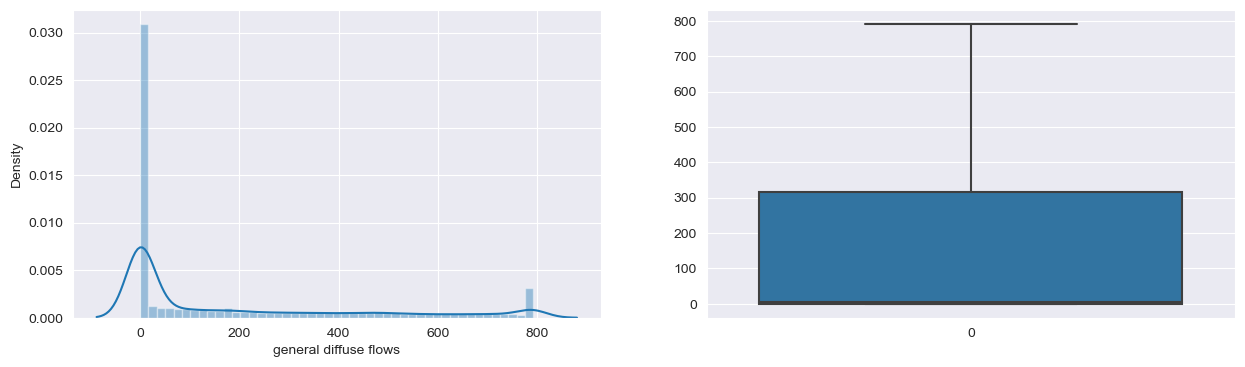

In [50]:
col_distribution(data, 'general diffuse flows')

The outliers are removed but the data is still very spread out. We can try binning the data into 3 categories, low, medium and high for intensity of solar radiation. THis breaks down the data into categories and makes it easier to understand.

In [51]:
# Binning the GDF data into 3 bins
bins = ['low','medium','high']
data['gdf_bins'] = pd.cut(data['general diffuse flows'], 
                          bins = [data['general diffuse flows'].min(),50,200,data['general diffuse flows'].max()],
                          labels = ['low','medium','high'])
gdf_bins = pd.DataFrame(data['gdf_bins'].value_counts())
gdf_bins.reset_index(inplace=True)
gdf_bins.columns = ['bin_values', 'count']
gdf_bins

,bin_values,count
0,low,29275
1,high,16629
2,medium,6676


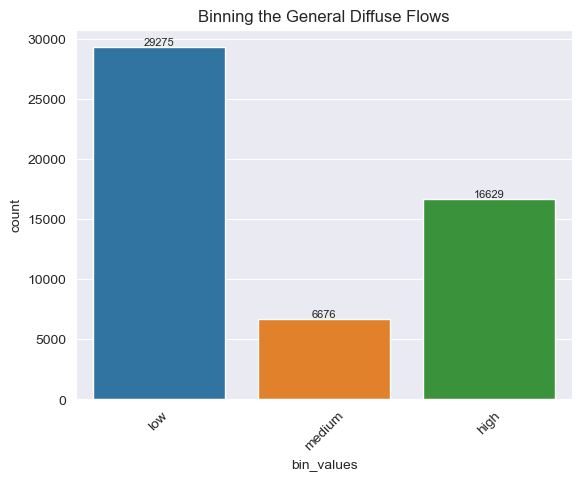

In [52]:
ax = sns.barplot(x = 'bin_values', y = 'count', data = gdf_bins)
label = ax.containers[0]
ax.bar_label(label, fontsize=8)
plt.xticks(rotation=45)
plt.title("Binning the General Diffuse Flows")
plt.show()


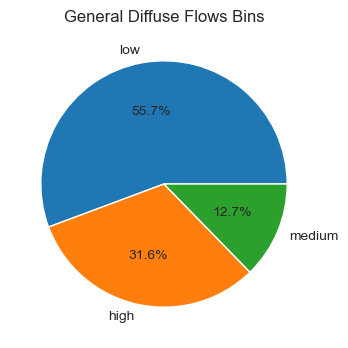

In [53]:
plt.figure(figsize=(15,4))
plt.pie(data['gdf_bins'].value_counts(), labels=data['gdf_bins'].value_counts().index, autopct='%1.1f%%')
plt.title('General Diffuse Flows Bins')
plt.show()

In [54]:
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone,gdf_bins
0,6.559,1982.577483,0.083,0.051,0.119,158.0,1,34055.69620,low
1,6.414,2018.780062,0.083,0.070,0.085,159.0,1,29814.68354,low
2,6.313,2018.780062,0.080,0.062,0.100,151.0,1,29128.10127,low
3,6.121,2044.830722,0.083,0.091,0.096,151.0,1,28228.86076,low
4,5.921,2081.569802,0.081,0.048,0.085,154.0,1,27335.69620,low


Diffuse Flows: The measure of diffuse solar radiation. (Mtr sqr per sec )

********** Data Distribution - diffuse flows *********
The skewness for the original data is 2.4612306021596178.
The kurtosis for the original data is 7.030322650683042.

********** Outlier Detection - diffuse flows *********
Q1: 0.122 | Q3: 100.45 | IQR: 100.328 | LL: -150.37 | UL: 250.942
# of Outliers on the Higher Side: 4621 | % of Outliers on the Higher Side: 8.788011334461709%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



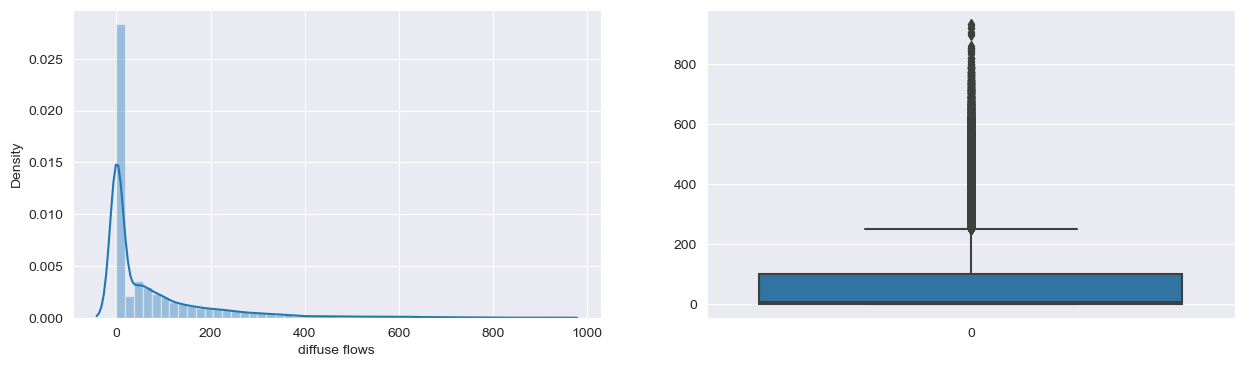

In [55]:
df_ll, df_ul = col_distribution(data, 'diffuse flows')

The skewness is going beyond 2, the data is substantially skewed. There are a little over 8.7% of outliers in the data. These outliers can be treated by capping using the upperlimit value. 

********** Data Distribution - diffuse flows *********
The skewness for the original data is 1.204089106712575.
The kurtosis for the original data is 0.057618789373761636.

********** Outlier Detection - diffuse flows *********
Q1: 0.122 | Q3: 100.45 | IQR: 100.328 | LL: -150.37 | UL: 250.942
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



(-150.37, 250.942)

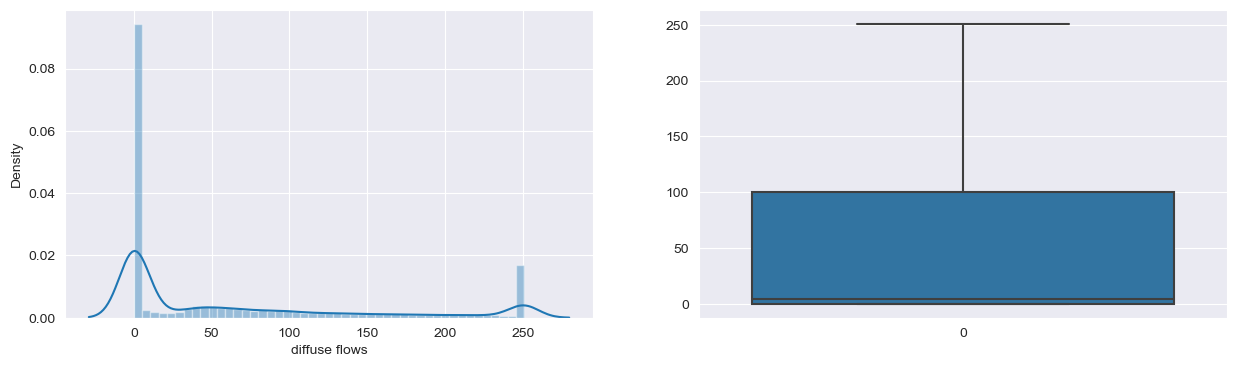

In [56]:
data['diffuse flows'] = np.where(data['diffuse flows'] >= df_ul, df_ul, data['diffuse flows'])
# checking the outliers again
col_distribution(data, 'diffuse flows')

Outliers are fixed and skewness has reduced to a certain amount. Trying the tansformation technique to fix the skewness.

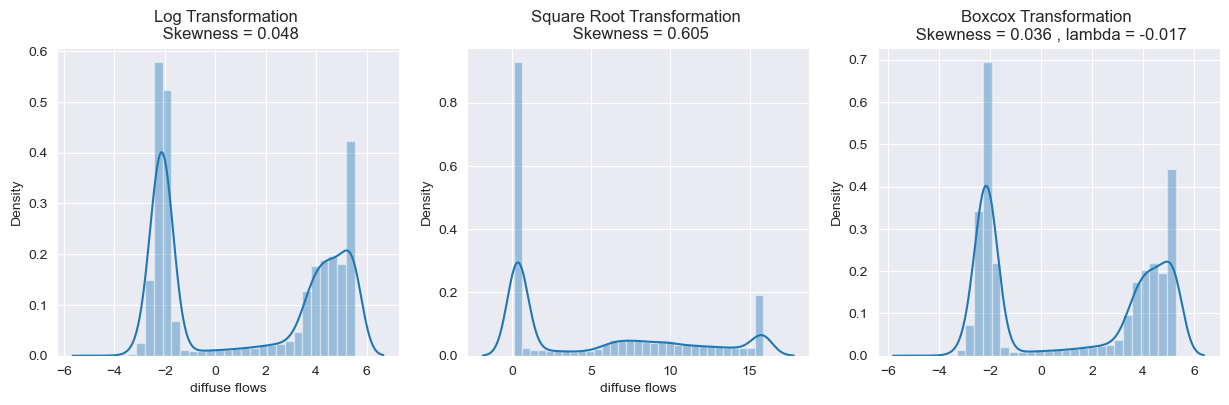

In [57]:
check_transformation(data, 'diffuse flows')

Transformation of the data is not helping much as the data distribution is not normal yet. 
Binning the data similar to General diffuse flows to get some understanding of the data.

In [58]:
# Binning the DF data into 3 bins
bins = ['low','medium','high']
data['df_bins'] = pd.cut(data['diffuse flows'], 
                          bins = [data['diffuse flows'].min(),50,200,data['diffuse flows'].max()],
                          labels = ['low','medium','high'])
df_bins = pd.DataFrame(data['df_bins'].value_counts())
df_bins.reset_index(inplace=True)
df_bins.columns = ['bin_values', 'count']
df_bins

,bin_values,count
0,low,32311
1,medium,13629
2,high,6642


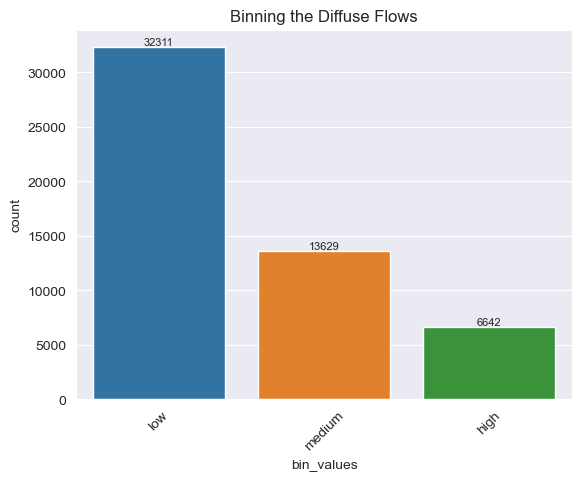

In [59]:
ax = sns.barplot(x = 'bin_values', y = 'count', data = df_bins)
label = ax.containers[0]
ax.bar_label(label, fontsize=8)
plt.xticks(rotation=45)
plt.title("Binning the Diffuse Flows")
plt.show()

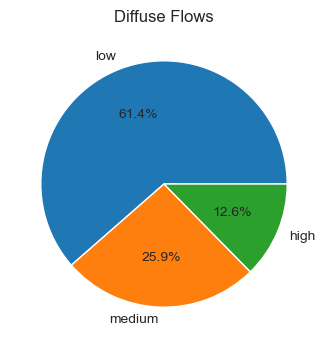

In [60]:
plt.figure(figsize=(15,4))
plt.pie(data['df_bins'].value_counts(), labels=data['df_bins'].value_counts().index, autopct='%1.1f%%')
plt.title('Diffuse Flows')
plt.show()

Air Quality Index: An index representing the air quality in the area. (particles in micrograms per cubic meter. )

********** Data Distribution - Air Quality Index (PM) *********
The skewness for the original data is -0.0016227562598891668.
The kurtosis for the original data is -1.222943099956878.

********** Outlier Detection - Air Quality Index (PM) *********
Q1: 152.0 | Q3: 157.0 | IQR: 5.0 | LL: 144.5 | UL: 164.5
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



(144.5, 164.5)

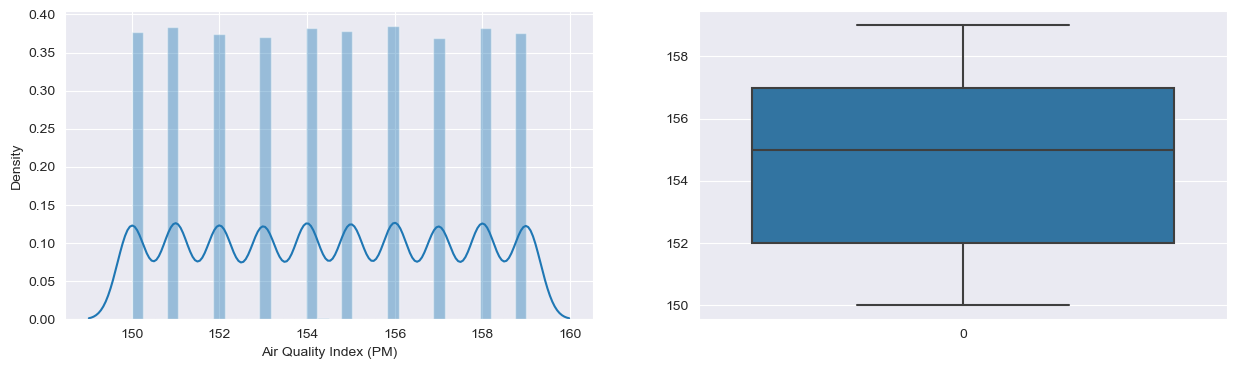

In [61]:
col_distribution(data, 'Air Quality Index (PM)')

There is a negligable amount of negetive skewness. The data looks like its uniformly distributed. There are no outliers either. Keeping this data as it is. 

Cloudiness: The level of cloud cover or cloudiness at the location. (1-Yes,0-No). As it a categorical value, no need to check for data distribution and outliers. Instead, we can plot a pie chart to see the data distribution.

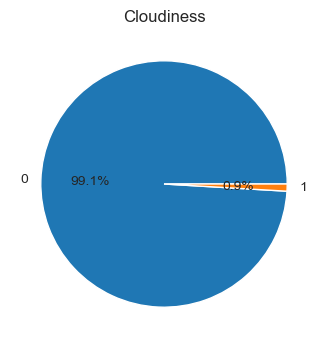

In [62]:
plt.figure(figsize=(15,4))
plt.pie(data['Cloudiness'].value_counts(), labels=data['Cloudiness'].value_counts().index, autopct='%1.1f%%')
plt.title('Cloudiness')
plt.show()

99.1% of the data says there is 0 cloud cover. Which means the sky is clear in almost all the areas.

********** Data Distribution -  Power Consumption in A Zone *********
The skewness for the original data is 0.031527861541815555.
The kurtosis for the original data is -0.5486460601780343.

********** Outlier Detection -  Power Consumption in A Zone *********
Q1: 24738.85899 | Q3: 36721.582445 | IQR: 11982.723455 | LL: 6764.773807500002 | UL: 54695.6676275
# of Outliers on the Higher Side: 0 | % of Outliers on the Higher Side: 0.0%
# of Outliers on the Lower Side: 0 | % of Outliers on the Lower Side: 0.0%



(6764.773807500002, 54695.6676275)

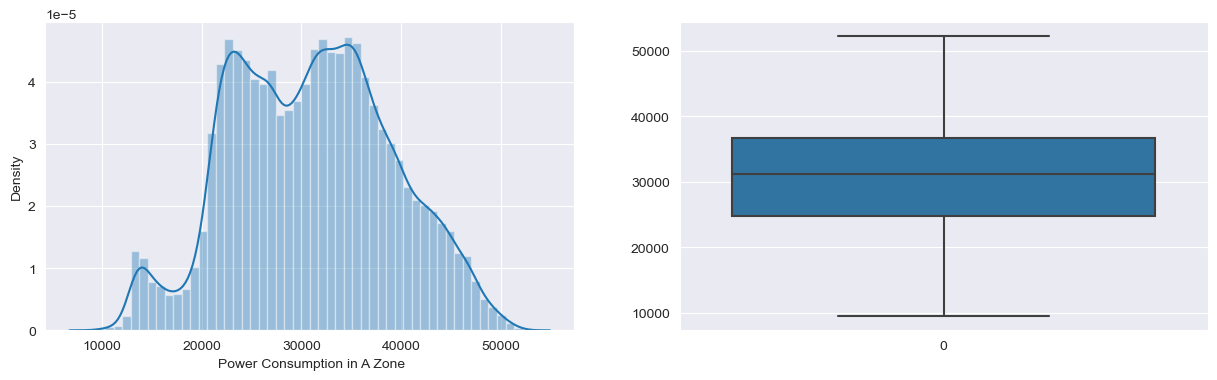

In [63]:
col_distribution(data, ' Power Consumption in A Zone')

Target variable, has no outliers. Skewness is not so significant. Data is fairly normally distributed.

In [64]:
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone,gdf_bins,df_bins
0,6.559,1982.577483,0.083,0.051,0.119,158.0,1,34055.69620,low,low
1,6.414,2018.780062,0.083,0.070,0.085,159.0,1,29814.68354,low,low
2,6.313,2018.780062,0.080,0.062,0.100,151.0,1,29128.10127,low,low
3,6.121,2044.830722,0.083,0.091,0.096,151.0,1,28228.86076,low,low
4,5.921,2081.569802,0.081,0.048,0.085,154.0,1,27335.69620,low,low


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Temperature                   52583 non-null  float64 
 1   Humidity                      52583 non-null  float64 
 2   Wind Speed                    52583 non-null  float64 
 3   general diffuse flows         52583 non-null  float64 
 4   diffuse flows                 52583 non-null  float64 
 5   Air Quality Index (PM)        52583 non-null  float64 
 6   Cloudiness                    52583 non-null  int64   
 7    Power Consumption in A Zone  52583 non-null  float64 
 8   gdf_bins                      52580 non-null  category
 9   df_bins                       52582 non-null  category
dtypes: category(2), float64(7), int64(1)
memory usage: 3.3 MB


Bi Variate analysis, with respect to the target variable.
1. Temeprature vs Power Consumption

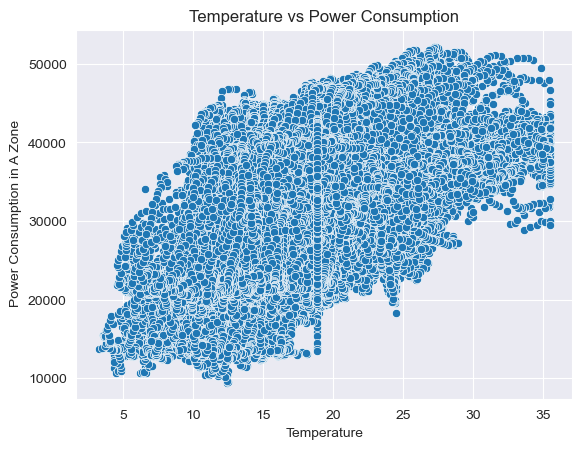

In [66]:
sns.scatterplot(x='Temperature', y=' Power Consumption in A Zone', data = data)
plt.title("Temperature vs Power Consumption")
plt.show()

There is a positive correlation between Temperature and Power Consumption. This could be because as the temperature rises, the use of air conditioners is increasing which results in high power consumption.

2. Humidity vs Power Consumption

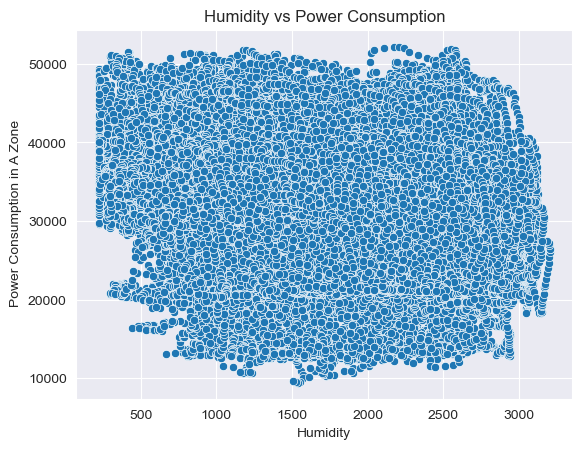

In [67]:
sns.scatterplot(x='Humidity', y=' Power Consumption in A Zone', data = data)
plt.title("Humidity vs Power Consumption")
plt.show()

There seems to be a negetive correlation between Humidity and Power Consumption. 

3. Wind Speed vs Power Consumption

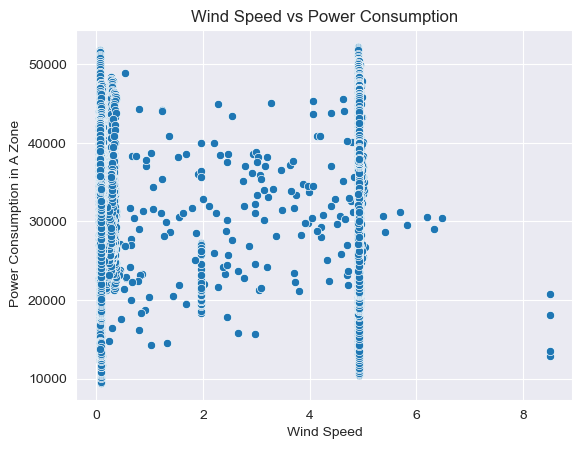

In [68]:
sns.scatterplot(x='Wind Speed', y=' Power Consumption in A Zone', data = data)
plt.title("Wind Speed vs Power Consumption")
plt.show()

Looking at some of the scattered data points, it looks like there is a positive correlation.
But most of the data points are saturated at certain values such as 1 and 5

4. General Diffuse FLows vs Power Consumption

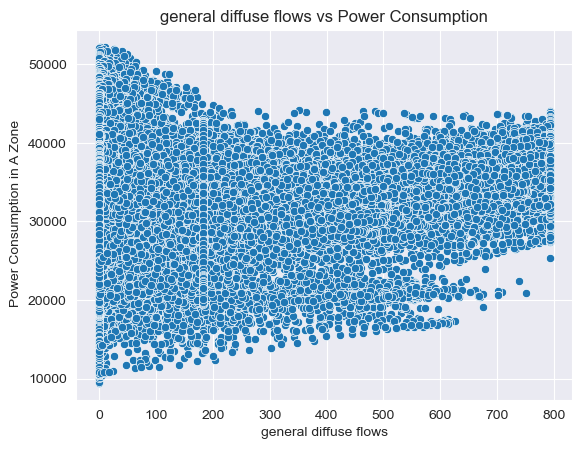

In [69]:
sns.scatterplot(x='general diffuse flows', y=' Power Consumption in A Zone', data = data)
plt.title("general diffuse flows vs Power Consumption")
plt.show()

The data is spread across but there is some positive correlation here

5. Diffuse flows vs Power Consumption

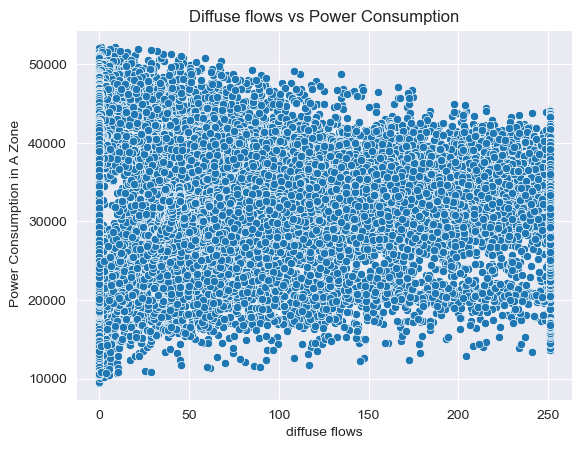

In [70]:
sns.scatterplot(x='diffuse flows', y=' Power Consumption in A Zone', data = data)
plt.title("Diffuse flows vs Power Consumption")
plt.show()

The data is spread across. 

6. Air Quality Index vs Power Consumption

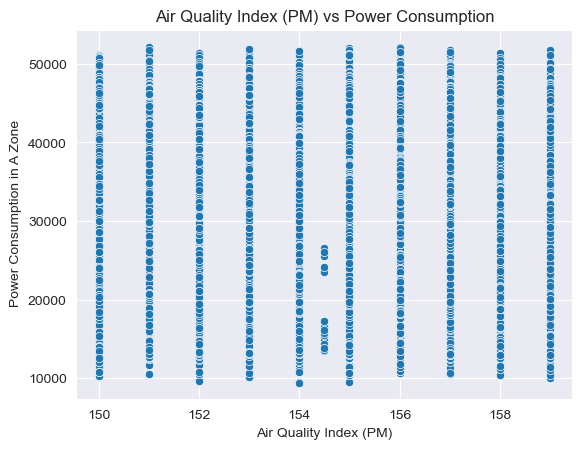

In [71]:
sns.scatterplot(x='Air Quality Index (PM)', y=' Power Consumption in A Zone', data = data)
plt.title("Air Quality Index (PM) vs Power Consumption")
plt.show()

Data is uniformly distributed across all the values if Air Quality Index. This indicates that the Air quality index does not have much effect on the power consumption.


Encoding the category columns using Label encoder

In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['gdf_bins'] = le.fit_transform(data['gdf_bins'])
data['df_bins'] = le.fit_transform(data['df_bins'])

In [73]:
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone,gdf_bins,df_bins
0,6.559,1982.577483,0.083,0.051,0.119,158.0,1,34055.69620,1,1
1,6.414,2018.780062,0.083,0.070,0.085,159.0,1,29814.68354,1,1
2,6.313,2018.780062,0.080,0.062,0.100,151.0,1,29128.10127,1,1
3,6.121,2044.830722,0.083,0.091,0.096,151.0,1,28228.86076,1,1
4,5.921,2081.569802,0.081,0.048,0.085,154.0,1,27335.69620,1,1


In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Temperature                   52583 non-null  float64
 1   Humidity                      52583 non-null  float64
 2   Wind Speed                    52583 non-null  float64
 3   general diffuse flows         52583 non-null  float64
 4   diffuse flows                 52583 non-null  float64
 5   Air Quality Index (PM)        52583 non-null  float64
 6   Cloudiness                    52583 non-null  int64  
 7    Power Consumption in A Zone  52583 non-null  float64
 8   gdf_bins                      52583 non-null  int64  
 9   df_bins                       52583 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 4.0 MB


Scaling the data using standard scaler.

In [75]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
data_scaled = ss.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled,columns = data.columns)

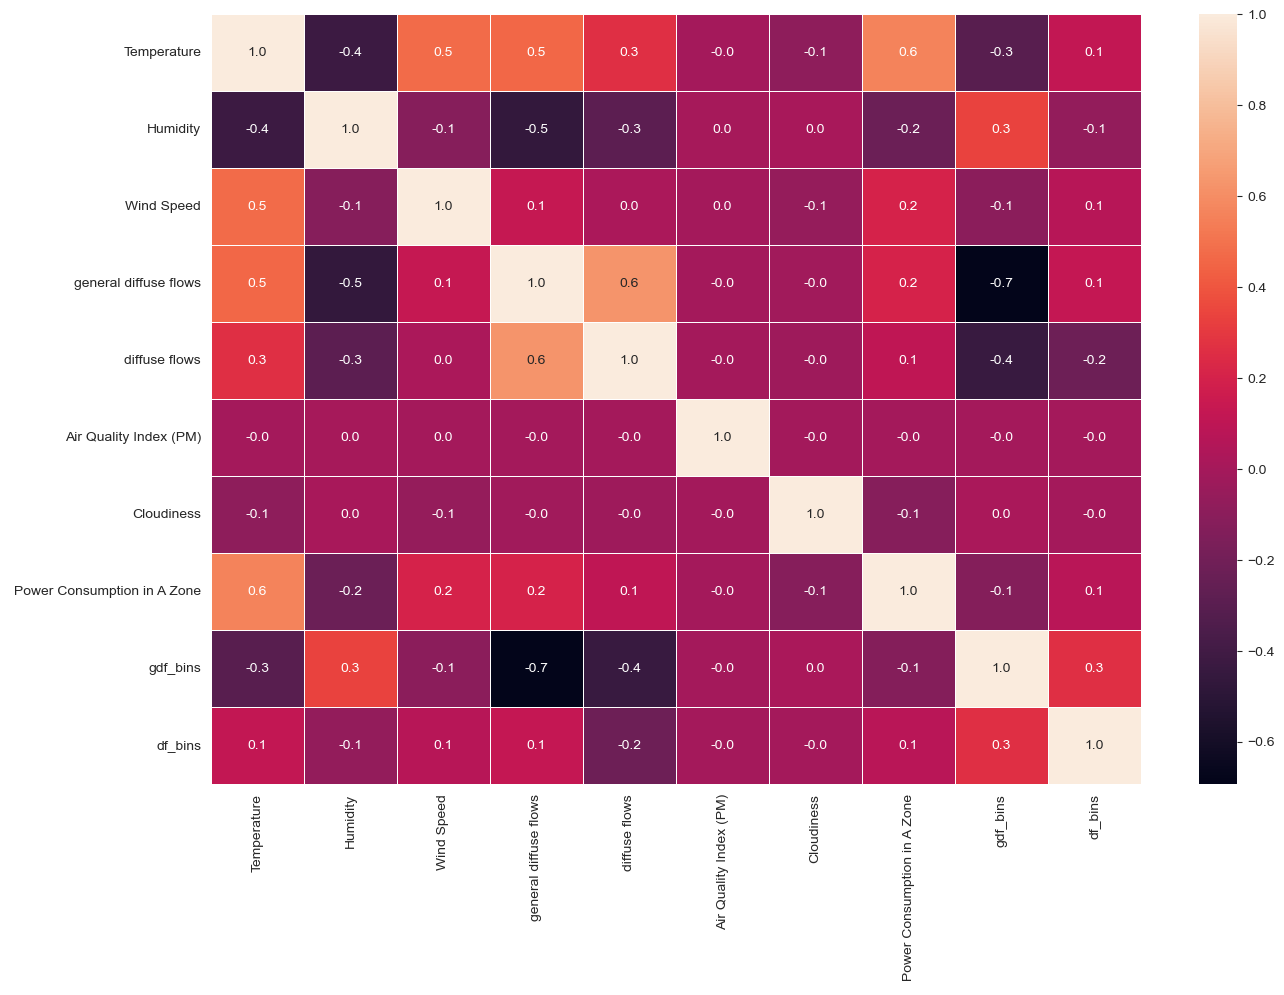

In [76]:
fig = plt.gcf()
fig.set_size_inches(15,10)
sns.heatmap(data_scaled.corr(),annot=True, fmt = ".1f", linewidth=0.5)
plt.show()

The heat map shows that Temperature is the feature that has highest correlation, next are wind speed and general diffuse flows which are also positively correlated. However humidity is negetively correlated.

The gdf_bins and df_bins are not much helpful here so we can drop these columns.

In [77]:
# dropping gdf_bins and df_bins
data_scaled.drop(['gdf_bins', 'df_bins'], axis=1, inplace=True)
data_scaled.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,-2.120885,0.279274,-0.798042,-0.701660,-0.729552,1.219354,10.300179,0.373255
1,-2.145960,0.330950,-0.798042,-0.701586,-0.729953,1.567661,10.300179,-0.155484
2,-2.163426,0.330950,-0.799321,-0.701617,-0.729776,-1.218791,10.300179,-0.241083
3,-2.196629,0.368135,-0.798042,-0.701504,-0.729823,-1.218791,10.300179,-0.353194
4,-2.231216,0.420577,-0.798895,-0.701672,-0.729953,-0.173872,10.300179,-0.464547


In [78]:
data_scaled.isna().sum()

Temperature                     0
Humidity                        0
Wind Speed                      0
general diffuse flows           0
diffuse flows                   0
Air Quality Index (PM)          0
Cloudiness                      0
 Power Consumption in A Zone    0
dtype: int64

Sperating the x and y features and splitting the data into train and test 

In [79]:
x = data_scaled.drop([' Power Consumption in A Zone'], axis=1)
y = data_scaled[' Power Consumption in A Zone']

In [80]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [81]:
print("The shape of X_train is:", x_train.shape)
print("The shape of X_test is:", x_test.shape)

print('')

print("The shape of Y_train is:", y_train.shape)
print("The shape of Y_test is:", y_test.shape)

The shape of X_train is: (42066, 7)
The shape of X_test is: (10517, 7)

The shape of Y_train is: (42066,)
The shape of Y_test is: (10517,)


Applying Linear Regression model.

In [82]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [83]:
x_train.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows',
       'diffuse flows', 'Air Quality Index (PM)', 'Cloudiness'],
      dtype='object')

In [84]:
y_pred = lr.predict(x_test)
y_pred_train = lr.predict(x_train)


In [85]:
from sklearn import metrics
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error - Test: {mse_test}')

mae_test = metrics.mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error - Test: {mse_test}')

rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, y_pred_train)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, y_pred)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.673135469948029
Mean Squared Error - Test: 0.670592968384187
Mean Absolute Error - Test: 0.670592968384187
Root Mean Squared Error - Test: 0.670592968384187
R-squared - Train: 0.32617369970478416
R-squared - Test: 0.3321428885705713


Checking the distribution of residuals in the linear regression model

<Axes: ylabel='Density'>

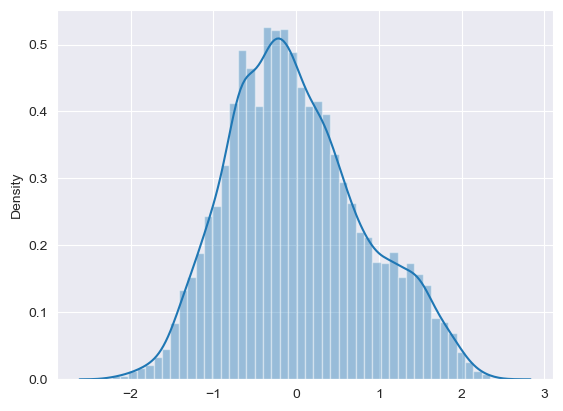

In [86]:
sns.distplot(x=y_test-y_pred)

The plot is giving abell curve, indicating that the model is performing well and there is no bias in the errors. 

In [87]:
lr_coeff_df = pd.DataFrame(lr.coef_, x.columns, columns = ['Coefficient'])
lr_coeff_df 

,Coefficient
Temperature,0.629448
Humidity,0.004265
Wind Speed,-0.092605
general diffuse flows,-0.051073
diffuse flows,-0.030887
Air Quality Index (PM),-0.000633
Cloudiness,-0.072894


Temperature has the most effect on power consumption. Rest all the features do not have much effect.

Random Forest model

In [88]:
xrf_train, xrf_test, yrf_train, yrf_test = train_test_split(x, y, train_size = 0.8, random_state = 42)

In [89]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators = 10, random_state=0)
rf_model.fit(xrf_train, yrf_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
yrf_test_pred = rf_model.predict(xrf_test)
yrf_train_pred = rf_model.predict(xrf_train)

In [91]:
print("The shape of Y_train is:", yrf_train_pred.shape)
print("The shape of Y_test is:", yrf_test_pred.shape)
print("The shape of Y_test is:", yrf_test.shape)

The shape of Y_train is: (42066,)
The shape of Y_test is: (10517,)
The shape of Y_test is: (10517,)


In [92]:
# Evaluating the model

mse_train = metrics.mean_squared_error(yrf_train, yrf_train_pred)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(yrf_test, yrf_test_pred)
print(f'Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(yrf_train, yrf_train_pred)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(yrf_test, yrf_test_pred)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.07411725409100749
Mean Squared Error - Test: 0.4025649892696069
R-squared - Train: 0.9258066803164601
R-squared - Test: 0.5990773784222125


The R2 test is much better compared to linear regression but its clear that the model is overfitting as the R2 for train data is 92% and test data is 59%

Support Vecor Machine

In [93]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(x_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [94]:
ysvr_train_pred = svr.predict(x_train)
ysvr_test_pred = svr.predict(x_test)

In [95]:
# Evaluating the model

mse_train = metrics.mean_squared_error(y_train, ysvr_train_pred)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, ysvr_test_pred)
print(f'Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, ysvr_train_pred)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, ysvr_test_pred)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.6291935038036583
Mean Squared Error - Test: 0.6308389083245469
R-squared - Train: 0.3701607629285435
R-squared - Test: 0.37173476168996344


Here is there isn't any overfitting or underfitting but the r2 score is very low.

Decision Tree Regressor Model

In [96]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [97]:
ydt_train_pred = dt.predict(x_train)
ydt_test_pred = dt.predict(x_test)

In [98]:

# Evaluating the model

mse_train = metrics.mean_squared_error(y_train, ydt_train_pred)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, ydt_test_pred)
print(f'Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, ydt_train_pred)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, ydt_test_pred)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.00011528974564000048
Mean Squared Error - Test: 0.7470691875307943
R-squared - Train: 0.9998845919339645
R-squared - Test: 0.2559786738825405


Again very high overfitting problem

Feature selection: Applying the Select K Best algorith to find the best features.

In [99]:
from sklearn.feature_selection import SelectKBest, f_regression
top_features = SelectKBest(score_func = f_regression, k=7)
x_train_features = top_features.fit(x_train, y_train)
x_test_features = top_features.transform(x_test)
df_scores = pd.DataFrame(x_train_features.scores_)
df_columns = pd.DataFrame(x.columns)
top_scores = pd.concat([df_columns, df_scores], axis=1)
top_scores.columns = ['Features','Scores']
top_scores = top_scores.sort_values(by='Scores', ascending=False)
print(top_scores.nlargest(10, 'Scores'))

                 Features        Scores
0             Temperature  18986.859310
1                Humidity   2186.817182
3   general diffuse flows   1818.627006
2              Wind Speed   1785.037987
6              Cloudiness    641.606955
4           diffuse flows    432.376184
5  Air Quality Index (PM)      0.202986


Selecting top 5 features 

In [100]:
x_train_top5 = x_train.drop(['Air Quality Index (PM)', 'diffuse flows'], axis=1)
x_test_top5 = x_test.drop(['Air Quality Index (PM)', 'diffuse flows'], axis=1)
x_train_top5.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,Cloudiness
25421,1.094106,-0.187268,1.265066,2.385842,-0.097086
24106,0.601248,-0.010917,-0.803582,1.762747,-0.097086
16072,-0.121610,0.301366,-0.801877,0.631172,-0.097086
14948,-0.292814,0.534454,-0.802303,-0.656152,-0.097086
19487,-0.097400,0.642585,1.262084,-0.266218,-0.097086


In [101]:
x_test_top5.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,Cloudiness
29170,2.135161,-0.851925,1.257397,2.385842,-0.097086
25116,0.699820,0.264592,1.260379,1.893284,-0.097086
12790,0.416210,-0.965239,1.262084,-0.692865,-0.097086
42990,0.324556,0.184492,-0.798042,2.064734,-0.097086
5653,-1.307928,-0.234249,1.262084,-0.701586,-0.097086


In [102]:
lr_top5 = LinearRegression()
lr_top5.fit(x_train_top5, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
y_pred_top5 = lr_top5.predict(x_test_top5)
y_pred_train_top5 = lr_top5.predict(x_train_top5)

In [104]:
mse_train = metrics.mean_squared_error(y_train, y_pred_train_top5)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, y_pred_top5)
print(f'Mean Squared Error - Test: {mse_test}')

mae_test = metrics.mean_absolute_error(y_test, y_pred_top5)
print(f'Mean Absolute Error - Test: {mse_test}')

rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_top5))
print(f'Root Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, y_pred_train_top5)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, y_pred_top5)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.6737134463838753
Mean Squared Error - Test: 0.6707948980175865
Mean Absolute Error - Test: 0.6707948980175865
Root Mean Squared Error - Test: 0.6707948980175865
R-squared - Train: 0.3255951300990937
R-squared - Test: 0.33194178276118724


Feature selection did not improve the score much.

In [105]:
top5_cols = ['Temperature','Humidity','Wind Speed','general diffuse flows','Cloudiness']

In [106]:
lr_coeff_df = pd.DataFrame(lr_top5.coef_, top5_cols, columns = ['Coefficient'])
lr_coeff_df 

,Coefficient
Temperature,0.629502
Humidity,0.004485
Wind Speed,-0.090776
general diffuse flows,-0.070433
Cloudiness,-0.072175


In [107]:
rf_top5 = RandomForestRegressor(n_estimators = 10, random_state=0)
rf_top5.fit(x_train_top5, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [108]:
yrf_pred_top5 = rf_top5.predict(x_test_top5)
yrf_pred_train_top5 = rf_top5.predict(x_train_top5)

In [109]:
# Evaluating the Random Forest model

mse_train = metrics.mean_squared_error(y_train, yrf_pred_train_top5)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, yrf_pred_top5)
print(f'Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, yrf_pred_train_top5)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, yrf_pred_top5)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.07396382122028011
Mean Squared Error - Test: 0.41530696405126677
R-squared - Train: 0.9259602706533856
R-squared - Test: 0.5863873878127216


In [110]:
svr_top5 = SVR(kernel='rbf')
svr_top5.fit(x_train_top5, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [111]:
ysvr_pred_top5 = svr_top5.predict(x_test_top5)
ysvr_pred_train_top5 = svr_top5.predict(x_train_top5)

In [112]:
# Evaluating the model

mse_train = metrics.mean_squared_error(y_train, ysvr_pred_train_top5)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, ysvr_pred_top5)
print(f'Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, ysvr_pred_train_top5)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, ysvr_pred_top5)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.6345759320983891
Mean Squared Error - Test: 0.6331311106272586
R-squared - Train: 0.36477281071630496
R-squared - Test: 0.36945191101768515


In [113]:
len(x_train.columns)

7

Applying RFE - Recursive Feature Elemination. For Feature selection.

In [114]:
from sklearn.feature_selection import RFE
rfe = RFE(lr, n_features_to_select = 5)
rfe = rfe.fit(x_train, y_train)

# tuples of (feature name, whether selected, ranking)
# note that the 'rank' is > 1 for non-selected features
list(zip(x_train.columns, rfe.support_, rfe.ranking_))

[('Temperature', True, 1),
 ('Humidity', False, 2),
 ('Wind Speed', True, 1),
 ('general diffuse flows', True, 1),
 ('diffuse flows', True, 1),
 ('Air Quality Index (PM)', False, 3),
 ('Cloudiness', True, 1)]

In [115]:
y_pred_rfe = rfe.predict(x_test)

r2_rfe = metrics.r2_score(y_test, y_pred_rfe)
print(r2_rfe)

0.33225590671661887


RFE also did not improve the score much for linear regression.

In [116]:
rfe = RFE(lr, n_features_to_select = 6)
rfe = rfe.fit(x_train, y_train)

# tuples of (feature name, whether selected, ranking)
# note that the 'rank' is > 1 for non-selected features
list(zip(x_train.columns, rfe.support_, rfe.ranking_))
y_pred_rfe = rfe.predict(x_test)

r2_rfe = metrics.r2_score(y_test, y_pred_rfe)
print(r2_rfe)

0.3321465288373635


K-fold Cross validation

In [117]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits = 5, shuffle = True, random_state = 100)
scores = cross_val_score(lr, x_train, y_train, scoring = 'r2', cv = kf)
scores

array([0.31833793, 0.31480207, 0.32423728, 0.3374532 , 0.33400254])

Cross validation scores for the 5 splits for LR model is in the range of 31%-33%. Which is not so good. 

In [118]:
kf = KFold(n_splits = 5, shuffle = True, random_state = 100)
scores = cross_val_score(rf_model, x_train, y_train, scoring = 'r2', cv = kf)
scores

array([0.57215721, 0.57177306, 0.57629919, 0.58393572, 0.58341695])

Cross validation scores for the Random Forest model are much higher. 57% to 58%. Lets apply hyperparameter tuning for random forest and check the score.

Hyper parameter tuning using the kfold cross validation on the random forest model

In [ ]:
from sklearn.model_selection import GridSearchCV
kf = KFold(n_splits = 5, shuffle = True, random_state = 100)

hyper_params = [{'n_estimators': list(range(10,200,50)),
                 'max_features': ['sqrt','log2'],
                 'max_depth': [10,20],
                 'max_leaf_nodes':[5,10],
                 'bootstrap':[True, False]}]
rfr = RandomForestRegressor()

model_cv = GridSearchCV(estimator = rfr,
                        param_grid = hyper_params,
                        scoring = 'r2',
                        cv = kf,
                        verbose = 1,
                        return_train_score = True)
model_cv.fit(x_train,y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,estimator,RandomForestRegressor()
,param_grid,"[{'bootstrap': [True, False], 'max_depth': [10, 20], 'max_features': ['sqrt', 'log2'], 'max_leaf_nodes': [5, 10], ...}]"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,60


In [120]:
pd.set_option('display.max_columns',None)

In [121]:
print("Best Parameters:", model_cv.best_params_)
print("Best Estimator:", model_cv.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': 10, 'n_estimators': 60}
Best Estimator: RandomForestRegressor(max_depth=20, max_features='sqrt', max_leaf_nodes=10,
                      n_estimators=60)


Training the random forest model using the best estimator. But the overfitting problem that was caused by Random Forest earlier is fixed now.

In [122]:
rfr_best = RandomForestRegressor(bootstrap=True, max_depth= 20, max_features='log2', max_leaf_nodes=10, n_estimators= 160)
rfr_best.fit(x_train, y_train)

,n_estimators,160
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,10
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [123]:
yrf_pred_best = rfr_best.predict(x_test)
yrf_pred_train_best = rfr_best.predict(x_train)

In [124]:
mse_train = metrics.mean_squared_error(y_train, yrf_pred_train_best)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, yrf_pred_best)
print(f'Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, yrf_pred_train_best)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, yrf_pred_best)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.678774326748443
Mean Squared Error - Test: 0.6785084565903663
R-squared - Train: 0.32052905581755775
R-squared - Test: 0.3242596936398664


There isn't much improvement in the r2 score using the beat estimator. 

Trying the XGBoost Regressor model.

In [125]:
import xgboost as xgb
xgb_regressor = xgb.XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state=42)
xgb_regressor.fit(x_train, y_train)

y_pred_xgb = xgb_regressor.predict(x_test)
y_pred_train_xgb = xgb_regressor.predict(x_train)

In [126]:
mse_train = metrics.mean_squared_error(y_train, y_pred_train_xgb)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, y_pred_xgb)
print(f'Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, y_pred_train_xgb)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, y_pred_xgb)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.43282825526218455
Mean Squared Error - Test: 0.47429124270576156
R-squared - Train: 0.5667275386200215
R-squared - Test: 0.5276437507345426


The score is much better using the XGBoost Regressor and there is no overfitting or underfitting. This is the best score so far. Lets perform the hyperparameter tuning on the XGBoost and see if it improves further.

In [127]:
kf = KFold(n_splits = 5, shuffle = True, random_state = 100)

hyper_params = [{'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'reg_alpha': [0, 0.1, 0.2],
    'reg_lambda': [1, 1.5, 2]}]

xgbr = xgb.XGBRegressor(random_state=42)

model_cv = GridSearchCV(estimator = xgbr,
                        param_grid = hyper_params,
                        scoring = 'r2',
                        cv = kf,
                        verbose = 1,
                        return_train_score = True)
model_cv.fit(x_train,y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"[{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'reg_alpha': [0, 0.1, ...], ...}]"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,objective,'reg:squarederror'


In [128]:
# 7. Print the best parameters and score
print("Best parameters:", model_cv.best_params_)
print("Best cross-validation score:", model_cv.best_score_)

# 8. Evaluate on the test set
best_model = model_cv.best_estimator_
y_pred = best_model.predict(x_test)
y_pred_train = best_model.predict(x_train)

Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 0.2, 'reg_lambda': 2}
Best cross-validation score: 0.5484936100976313


In [129]:
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
print(f'Mean Squared Error - Train: {mse_train}')

mse_test = metrics.mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error - Test: {mse_test}')

r2_train = metrics.r2_score(y_train, y_pred_train)
print(f'R-squared - Train: {r2_train}')

r2_test = metrics.r2_score(y_test, y_pred)
print(f'R-squared - Test: {r2_test}')

Mean Squared Error - Train: 0.3456324904143181
Mean Squared Error - Test: 0.44359288926967555
R-squared - Train: 0.6540127913691981
R-squared - Test: 0.5582168623209414


XGBoost with the best parameters is giving a score of 55%. Which is the best score so far.

Text(0, 0.5, 'y_pred')

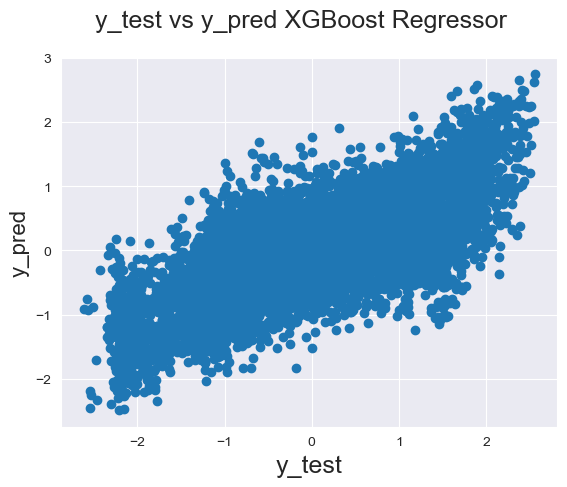

In [130]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred XGBoost Regressor', fontsize=18)              # Plot heading
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16)

Text(0, 0.5, 'Power Consumption')

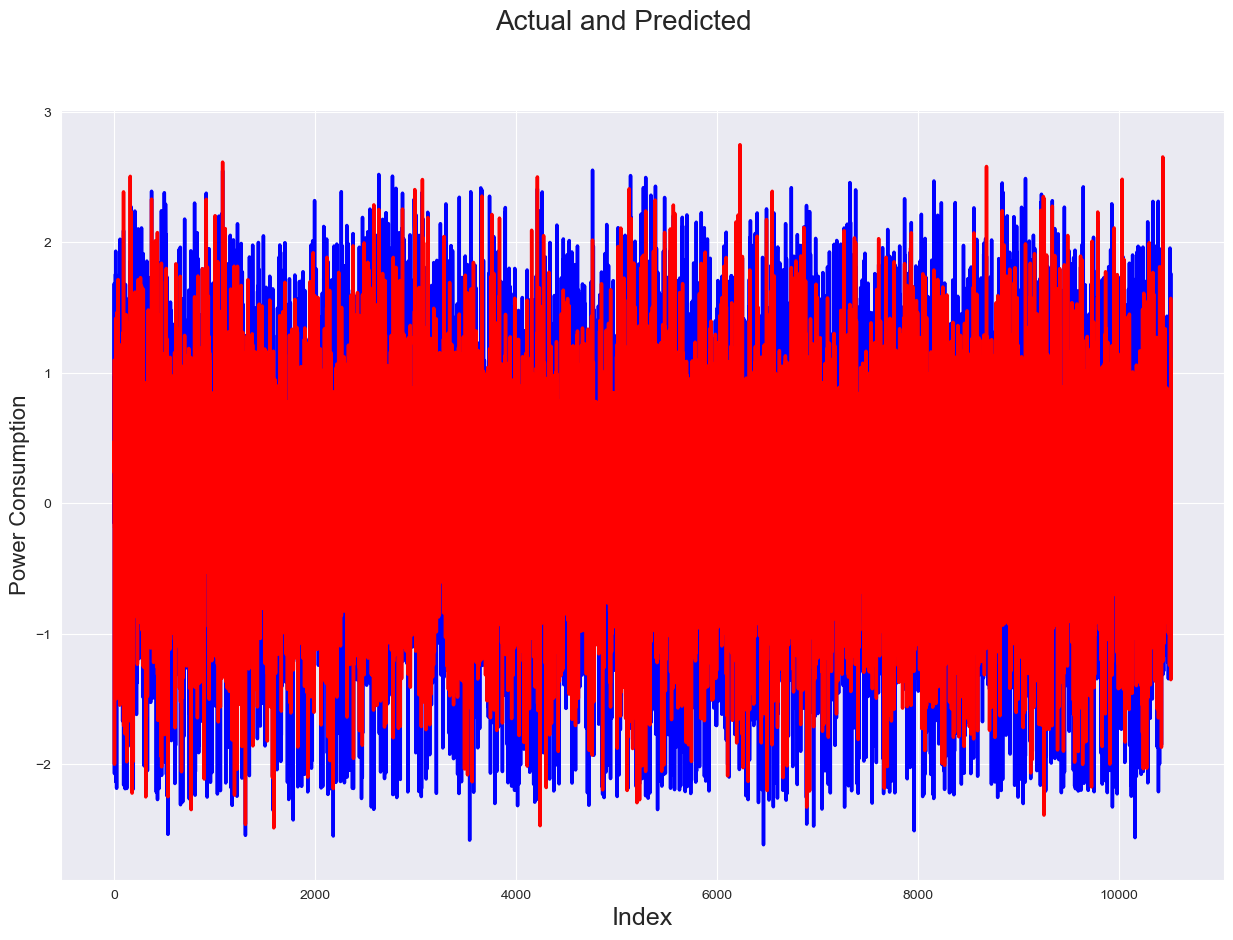

In [133]:
# Actual vs Predicted
c = [i for i in range(1,10518,1)]
fig = plt.figure(figsize = (15,10))
plt.plot(c,y_test, color="blue", linewidth=2.5, linestyle="-")     #Plotting Actual
plt.plot(c,y_pred, color="red",  linewidth=2.5, linestyle="-")  #Plotting predicted
fig.suptitle('Actual and Predicted', fontsize=20)              # Plot heading
plt.xlabel('Index', fontsize=18)                               # X-label
plt.ylabel('Power Consumption', fontsize=16)